In [2]:
!nvidia-smi || true

import sys
print(sys.version)

/bin/bash: line 1: nvidia-smi: command not found
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [3]:
%%bash
set -e

cd /content

if [ ! -f /content/bin/micromamba ]; then
  curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xvj -C /content bin/micromamba
fi

if [ ! -d /content/rtmdet_env ]; then
  /content/bin/micromamba create -y -p /content/rtmdet_env python=3.10
fi

/content/bin/micromamba run -p /content/rtmdet_env python -V

bin/micromamba
Fetch Shard Index for conda-forge/linux-64                                                      ⧖ Starting
Fetch Shard Index for conda-forge/linux-64                                                ✔ Done (0.1 sec)
Fetch Shard Index for conda-forge/noarch                                                        ⧖ Starting
Fetch Shard Index for conda-forge/noarch                                                  ✔ Done (0.2 sec)
Fetching and Parsing Packages' Shards                                                           ⧖ Starting
Fetching and Parsing Packages' Shards                                                     ✔ Done (8.0 sec)

Resolving Environment                                                                           ⧖ Starting
Resolving Environment                                                                     ✔ Done (0.2 sec)

Transaction

  Prefix: /content/rtmdet_env

  Updating specs:

   - python=3.10
   - pip


  Package               Version  Bui

In [4]:
%%bash
set -e

PY="/content/bin/micromamba run -p /content/rtmdet_env python"

# 基本ツール更新
$PY -m pip install -U pip setuptools wheel

# PyTorch / torchvision
$PY -m pip install \
  torch==2.1.0 torchvision==0.16.0 \
  --index-url https://download.pytorch.org/whl/cu121

# 重要: torch/torchvision導入後に NumPy 1.x へ戻す
$PY -m pip install --force-reinstall --no-cache-dir "numpy==1.26.4"

# 確認
$PY - <<'PY'
import sys
import numpy as np
import torch

print("python:", sys.version)
print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("device:", "cuda:0" if torch.cuda.is_available() else "cpu")

x = torch.tensor([1, 2, 3])
print("tensor:", x)
print("numpy:", x.numpy())

PY

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 GB 19.8 MB/s  0:00:38
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 89.6 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 MB 59.5 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 84.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 78.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 124.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 87.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 17.4 MB/s  0:00:00

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 208.7 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
python: 3.10.20 | packaged by conda-forge | (main, Jun 11 2026, 03:31:56) [GCC 14.3.0]
numpy: 1.26.4
torch: 

In [5]:
%%bash
PY="/content/bin/micromamba run -p /content/rtmdet_env python"
$PY -m pip check || true

contourpy 1.3.2 requires numpy, which is not installed.
matplotlib 3.10.9 requires numpy, which is not installed.
torchvision 0.16.0+cu121 requires numpy, which is not installed.


In [5]:
%%bash
set -e

# パスの定義
MAMBA_EXE="/content/bin/micromamba"
ENV_PATH="/content/rtmdet_env"
PY="$MAMBA_EXE run -p $ENV_PATH python"

# 1. 既存の衝突パッケージを削除
$PY -m pip uninstall -y numpy opencv-python opencv-python-headless opencv-contrib-python mmcv mmengine mmdet || true

# 2. NumPy 1.26.4 を優先的にインストール (NumPy 2.x を避ける)
$PY -m pip install --no-cache-dir "numpy==1.26.4"

# 3. OpenCV を依存解決なしでインストール
$PY -m pip install --no-deps "opencv-python-headless==4.8.1.78"

# 4. その他の必須ライブラリ
$PY -m pip install addict yapf termcolor rich pyyaml matplotlib packaging pillow pycocotools scipy shapely six terminaltables tqdm requests

# 5. OpenMMLab 関連 (依存解決なしでインストールし、NumPy の上書きを防ぐ)
$PY -m pip install --no-deps "mmengine==0.10.7"
$PY -m pip install --no-deps "mmcv==2.1.0" -f https://download.openmmlab.com/mmcv/dist/cu121/torch2.1.0/index.html

# 6. 整合性確認
$PY - <<'PY'
import numpy as np
import cv2
import torch
import mmcv
print("\n--- Dependency Check ---")
print(f"NumPy version: {np.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"Torch version: {torch.__version__}")
print(f"MMCV version:  {mmcv.__version__}")
if np.__version__.startswith('1.'):
    print("SUCCESS: NumPy 1.x is active.")
else:
    print("WARNING: NumPy 2.x is active, which may cause issues.")
PY

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 207.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 MB 48.0 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.3/770.3 kB 35.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 105.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 67.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 89.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 107.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.2 MB/s  0:00:00

Looking in links: https://download.openmmlab.com/mmcv/dist/cu121/torch2.1.0/index.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.1/94.1 MB 24.6 MB/s  0:00:03

--- Dependency Check ---
NumPy version: 1.26.

In [6]:
%%bash
set -e

cd /content

if [ ! -d /content/mmdetection ]; then
  git clone -b v3.3.0 https://github.com/open-mmlab/mmdetection.git
fi

cd /content/mmdetection
git checkout v3.3.0

echo "MMDetection repo ready."

MMDetection repo ready.


Cloning into 'mmdetection'...
Note: switching to '44ebd17b145c2372c4b700bfb9cb20dbd28ab64a'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 44ebd17b bump version to 3.3.0 (#11347)


In [7]:
%%bash
set -e

PY="/content/bin/micromamba run -p /content/rtmdet_env python"

cd /content/mmdetection
export PYTHONPATH=/content/mmdetection:$PYTHONPATH

$PY - <<'PY'
import sys
import numpy as np
import cv2
import torch
import mmcv
import mmengine
import mmdet

print("python:", sys.version)
print("numpy:", np.__version__)
print("opencv:", cv2.__version__)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("device:", "cuda:0" if torch.cuda.is_available() else "cpu")
print("mmcv:", mmcv.__version__)
print("mmengine:", mmengine.__version__)
print("mmdet:", mmdet.__version__)
PY

python: 3.10.20 | packaged by conda-forge | (main, Jun 11 2026, 03:31:56) [GCC 14.3.0]
numpy: 1.26.4
opencv: 4.8.1
torch: 2.1.0+cu121
cuda available: False
device: cpu
mmcv: 2.1.0
mmengine: 0.10.7
mmdet: 3.3.0


In [14]:
%%bash
set -e

PY="/content/bin/micromamba run -p /content/rtmdet_env python"

cd /content/mmdetection

# 1. pkg_resources を含む旧バージョンの setuptools に変更
$PY -m pip install "setuptools<70.0.0" "wheel"

# 2. --no-build-isolation を維持しつつ、インストールを実行
$PY -m pip install --no-build-isolation -e .

echo "Installation finished."

Obtaining file:///content/mmdetection
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for mmdet (pyproject.toml): started
  Building editable for mmdet (pyproject.toml): finished with status 'done'
  Created wheel for mmdet: filename=mmdet-3.3.0-0.editable-py3-none-any.whl size=14228 sha256=be7b34edd0a038544e8eee31d7926e9d021bed141fd05c944f8dcfc58af732d5
  Stored in directory: /tmp/pip-ephem-wheel-cache-iz289non/wheels/dd/94/f2/e7b790109d97f93a689af3b78116898c605c5f98f46eb6c693
Successfully built mmdet
  Attempting uninstall: mmdet
    Found existing installation: mmdet 3.3.0
    Uninstalling mmdet-3.3.0:
      Successfully uninstalled mmdet-3.3.0
Installation finished.


In [15]:
%%bash
PY="/content/bin/micromamba run -p /content/rtmdet_env python"

cd /content/mmdetection
export PYTHONPATH=/content/mmdetection:$PYTHONPATH
export MPLBACKEND=Agg

# GPU/CPU 自動判定
DEVICE=$($PY - <<'PY'
import torch
print("cuda:0" if torch.cuda.is_available() else "cpu")
PY
)
echo "Using device: ${DEVICE}"

# チェックポイントと出力ディレクトリの準備
mkdir -p checkpoints outputs/demo_auto

wget -nc -O checkpoints/rtmdet-ins_tiny.pth \
https://download.openmmlab.com/mmdetection/v3.0/rtmdet/rtmdet-ins_tiny_8xb32-300e_coco/rtmdet-ins_tiny_8xb32-300e_coco_20221130_151727-ec670f7e.pth

# デモ実行
$PY demo/image_demo.py \
  demo/demo.jpg \
  configs/rtmdet/rtmdet-ins_tiny_8xb32-300e_coco.py \
  --weights checkpoints/rtmdet-ins_tiny.pth \
  --device "${DEVICE}" \
  --out-dir outputs/demo_auto

echo "Demo finished. Result is in outputs/demo_auto"

Using device: cpu
Loads checkpoint by local backend from path: checkpoints/rtmdet-ins_tiny.pth
06/24 03:59:59 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "function" registry tree. As a workaround, the current "function" registry in "mmengine" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.
Inference ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   
results have been saved at outputs/demo_auto
Demo finished. Result is in outputs/demo_auto


File ‘checkpoints/rtmdet-ins_tiny.pth’ already there; not retrieving.
/content/rtmdet_env/lib/python3.10/site-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '
/content/rtmdet_env/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Found result image: /content/mmdetection/outputs/demo_auto/vis/demo.jpg


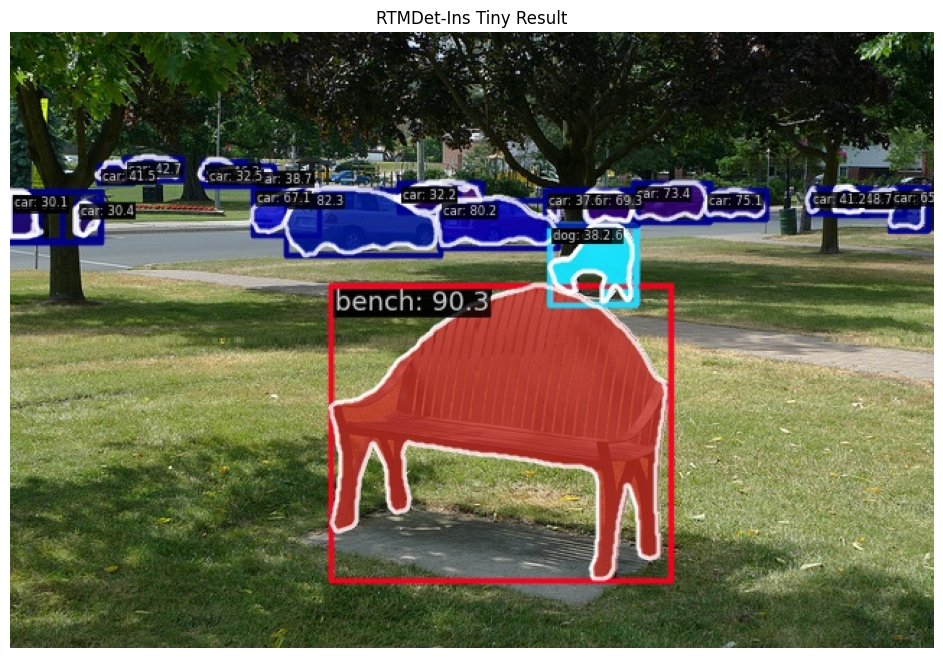

In [17]:
import os
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

# Search recursively for the result image
result_root = '/content/mmdetection/outputs/demo_auto'
image_extensions = ('.jpg', '.png', '.jpeg')
result_paths = list(Path(result_root).rglob('*'))
result_files = [str(p) for p in result_paths if p.suffix.lower() in image_extensions]

if result_files:
    # Usually the visualization is the one in vis_data or the largest file
    result_path = result_files[0]
    print(f"Found result image: {result_path}")
    img = Image.open(result_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title("RTMDet-Ins Tiny Result")
    plt.show()
else:
    print(f"No result image found in {result_root}. Checking directory structure:")
    !ls -R {result_root}